## Загрузка датасета
Будем выполнять разведочный анализ на датасете "Netflix Movies and Series", содержащем преимущественно текcтовые данные. Импортируем библиотеки:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Загрузим данные, определим размеры датасета и выведем первые 10 записей:

In [2]:
df = pd.read_csv('netflix_titles.csv')
print(f"Исходный датасет содержит {df.shape[0]} записей, {df.shape[1]} признаков\n")
df.head(10)

Исходный датасет содержит 8807 записей, 12 признаков



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


И последние 5:

In [3]:
df.tail(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


Определим типы данных признаков в датасете:

In [4]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

## Чистка датасета
Оценим число дубликатов в записях:

In [5]:
duplicate_rows = df[df.duplicated()]
print(f"В датасете всего {duplicate_rows.shape[0]} дубликатов")

В датасете всего 0 дубликатов


Прекрасно, все значения уникальные. По выведенным записям таблицы уже можно заметить, что в некоторых столбцах (например: "director", "cast", "country") отсутствую значения. Увидим точное количество записей с отсутствующими значениями:

In [6]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


Буду избавляться от таких записей путём их удаления, но сначала уберу все столбцы с признаками, которые в дальнейшем не будут использоваться в анализе:

In [7]:
df = df.drop(['director','cast','description', 'date_added'], axis=1)
df.head(5)

,show_id,type,title,country,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,United States,2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,TV Show,Ganglands,NaN,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,TV Show,Jailbirds New Orleans,NaN,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,s5,TV Show,Kota Factory,India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


Удалим записи с NaN:

In [8]:
df = df.dropna()
print(df.isnull().sum())
print(f"Размерность таблицы после чистки: {df.shape}")

show_id         0
type            0
title           0
country         0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64
Размерность таблицы после чистки: (7970, 8)


Разделим жанры ("listed_in") по методу горячего кодирования для дальнейшей работы с ними:

In [9]:
genres = df['listed_in'].str.get_dummies(sep=', ')
df = df.drop('listed_in', axis=1)
df = pd.concat([df, genres], axis=1)
df.head(5).T

,0,1,4,7,8
show_id,s1,s2,s5,s8,s9
type,Movie,TV Show,TV Show,Movie,TV Show
title,Dick Johnson Is Dead,Blood & Water,Kota Factory,Sankofa,The Great British Baking Show
country,United States,South Africa,India,"United States, Ghana, Burkina Faso, United Kin...",United Kingdom
release_year,2020,2021,2021,1993,2021
rating,PG-13,TV-MA,TV-MA,TV-MA,TV-14
duration,90 min,2 Seasons,2 Seasons,125 min,9 Seasons
Action & Adventure,0,0,0,0,0
Anime Features,0,0,0,0,0
Anime Series,0,0,0,0,0


Также уже можно было заметить, что в признаке "country" часто указаны несколько стран производства. Аналогично разделим и этот признак для дальнейшго использования при построении матриц корреляций:

In [10]:
countries = df['country'].str.get_dummies(sep=', ')
df = df.drop('country', axis=1)
df = pd.concat([df, countries], axis=1)

## Базовая статистика для признаков
Выведем общее количество значений каждого категориального признака, количество уникальных значений, моду и насколько часто мода встречается в записях

In [11]:
df.describe(include=['object', 'str', 'category'])

,show_id,type,title,rating,duration
count,7970,7970,7970,7970,7970
unique,7970,2,7970,14,212
top,s1,Movie,Dick Johnson Is Dead,TV-MA,1 Season
freq,1,5687,1,2931,1456


И единственного числового (за исключением раздробленных жанров) - года выпуска:

In [12]:
df['release_year'].describe()

count    7970.000000
mean     2013.885320
std         8.960918
min      1942.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

## Построение диаграмм, визуализация основных признаков
### Оценка размаха количества фильмов по году выпуска
Построим диграмму размаха для годов выпуска фильма/сериала:

<Axes: xlabel='release_year'>

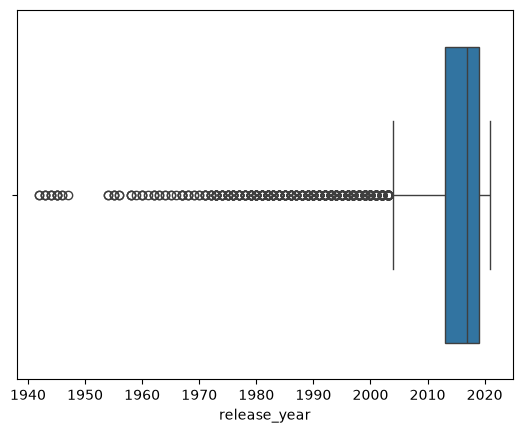

In [13]:
sns.boxplot(x=df['release_year'])

Как уже можно было понять по предыдущей аналитике по времени выпуска и можно заметить сейчас, большая часть контента на платформе выпущена в период с 2013 по 2019 годы. Период 1940-1950 можно в данном случае назвать статистической аномалией, так как платформа ориентирована преимущественно на выпуск современного контента. Это подтверждают и в том числе другие типы диаграмм:

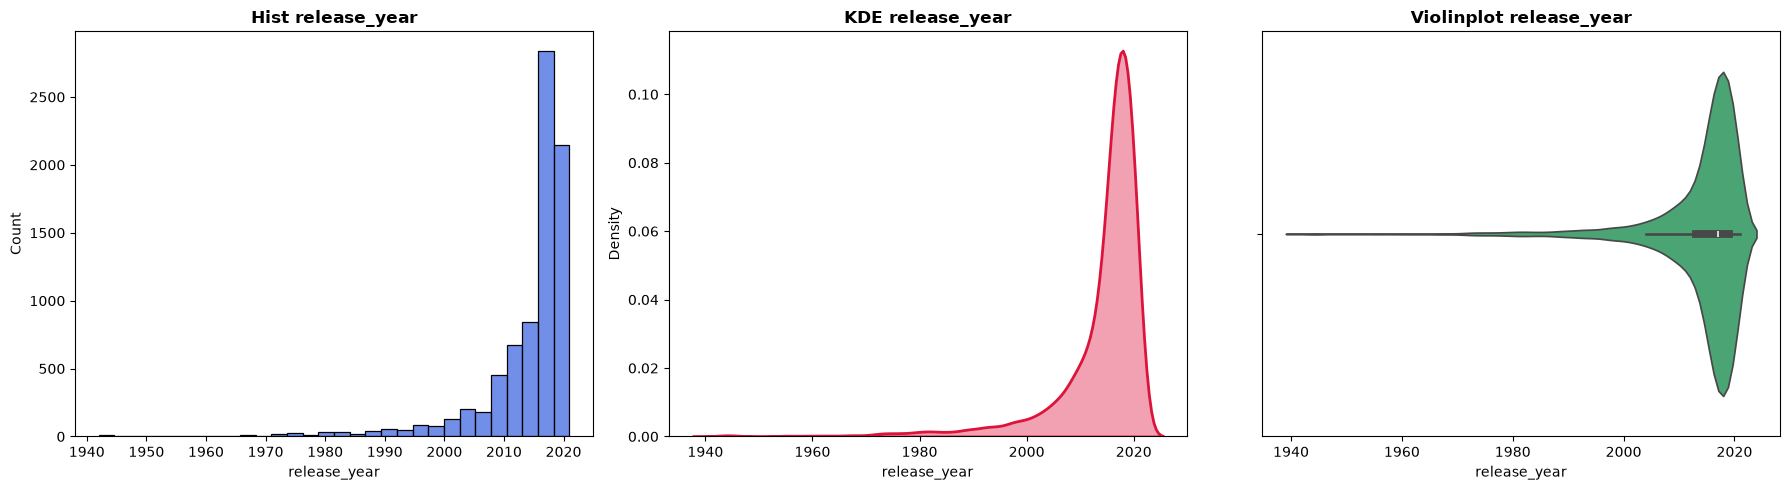

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x='release_year', kde=False, ax=axes[0], bins=30, color='royalblue')
axes[0].set_title('Hist release_year', fontsize=12, fontweight='bold')

sns.kdeplot(data=df, x='release_year', ax=axes[1], color='crimson', fill=True, alpha=0.4, linewidth=2)
axes[1].set_title('KDE release_year', fontsize=12, fontweight='bold')

sns.violinplot(data=df, x='release_year', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Violinplot release_year', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Анализ корреляции сопродюсертсва стран, связи стран и жанров
Построим матрицу корреляции сопродюсерства среди наиболее задействованных в съемке стран:

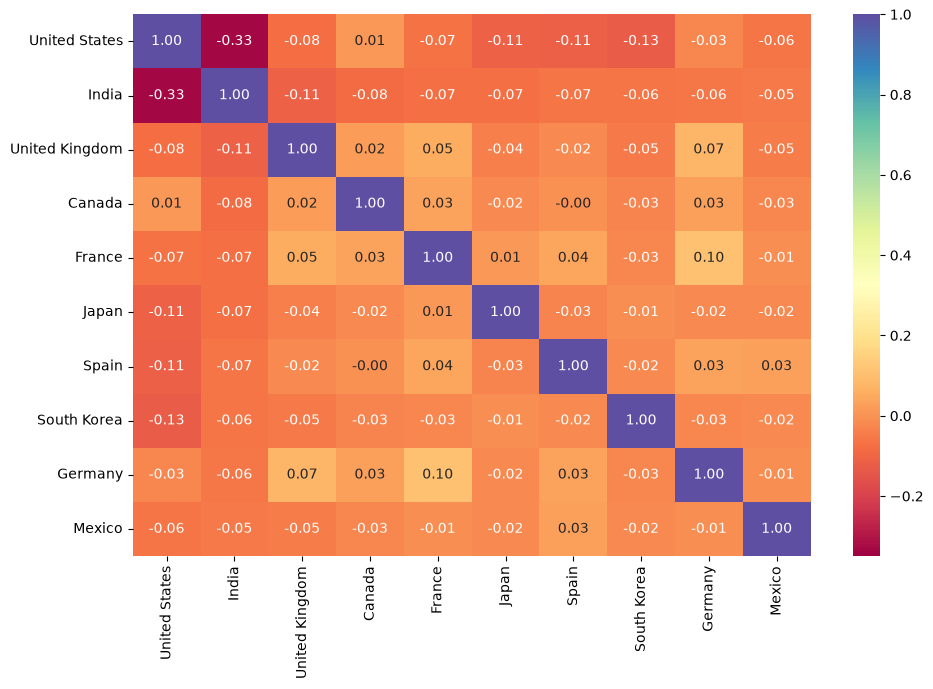

In [16]:
top_countries = countries.sum().nlargest(10).index
top_genres = genres.sum().nlargest(10).index

matrix_codirecting_countries = countries[top_countries].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(matrix_codirecting_countries, annot=True, fmt='.2f', cmap='Spectral', vmin=-0.35, vmax=1.0)
plt.tight_layout()
plt.show()

Явной корреляции совместного производства контента между странами не выявлено. Небольшая прямая зависимость наблюдается между европейскими странами (Германия, Франция, Соединённое королевство) - что объясняется частым сотрудничеством европейского кинематографа, обратная между США и Индией, США и Южной Кореей - три эти страны имеют достаточно независимые, большие киноиндустрии. Оценим связь стран и жанров:

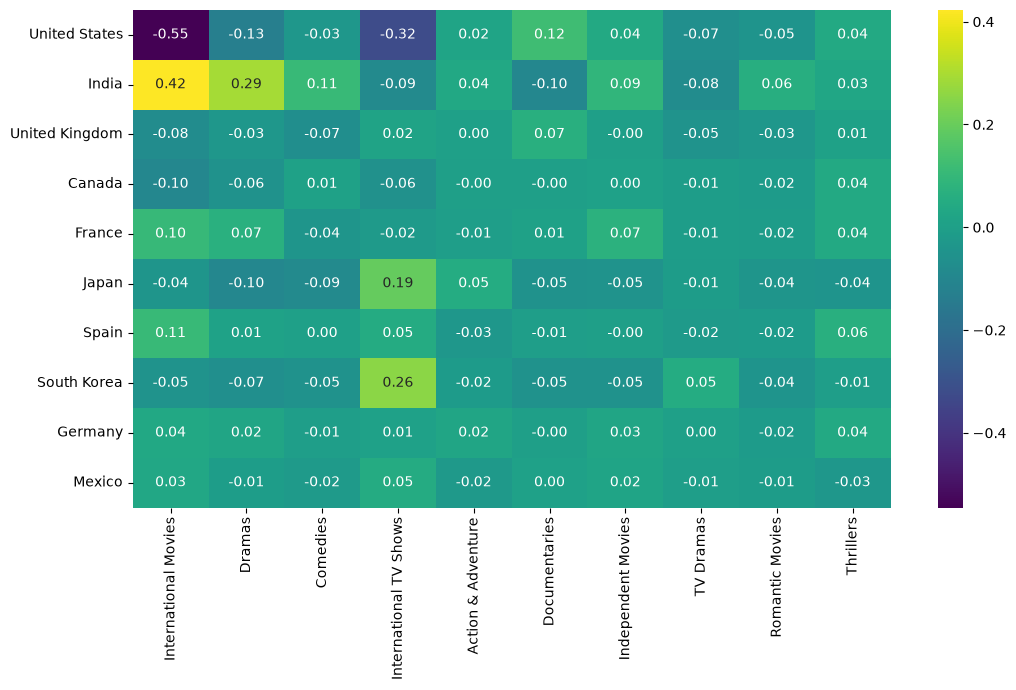

In [19]:
matrix_genres_countries = pd.DataFrame({
    c: genres[top_genres].apply(lambda g: countries[top_countries][c].corr(g)) 
    for c in top_countries
}).T

plt.figure(figsize=(11, 7))
sns.heatmap(matrix_genres_countries, annot=True, fmt=".2f", cmap='viridis')
plt.tight_layout()
plt.show()

Поскольку Нетфликс - американская платформа, ожидаемо, что тайтлы произведенные в США не будут считаться на Нетфликсе зарубежными (средняя обратная корреляция для жанров "зарубежные фильмы" и "зарубежные сериалы"), наиболее популярными же странами, чьи работы входят в эти жанры оказались Индия, Южная Корея, Япония (у всех 3 крупные индустрии производства контента). Также в США любят документалки, в Индии наоборот они менее распространены (но чаще снимают драмы). 

### Анализ распределения рейтингов тайтлов по году выпуска:
Перед построением следующей диаграммы выдвинем предположения:
Рейтинг - год выпуска: взрослый контент (TV-MA, R) меньше попадается в старых тайтлах, семейный контент - встречается постоянно.   
Проверим:    

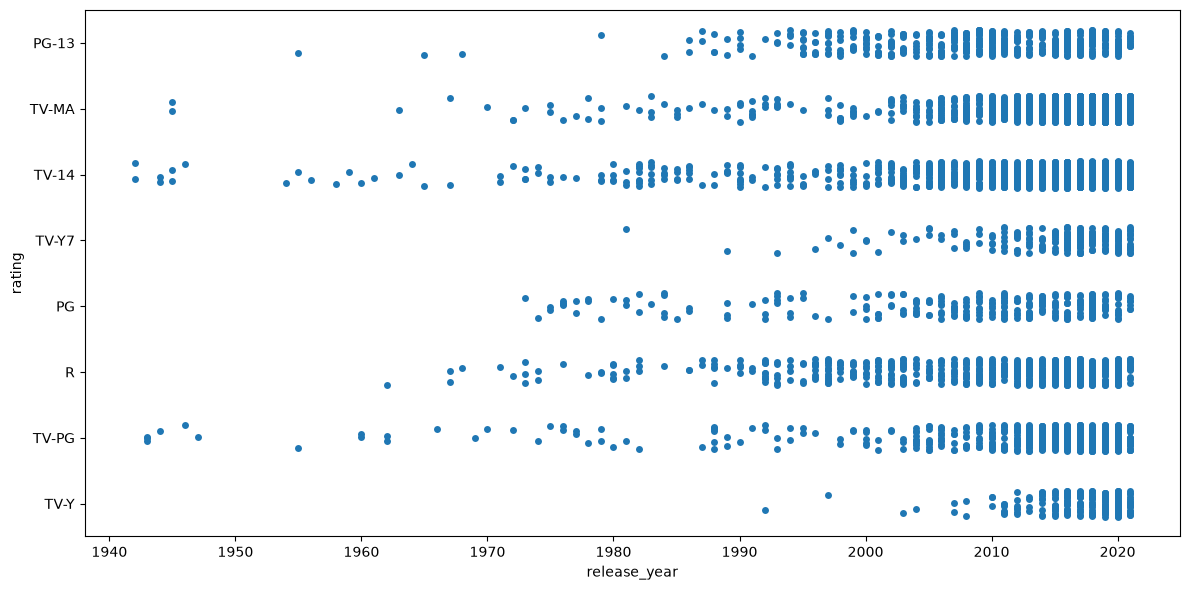

In [25]:
top_ratings = df['rating'].value_counts().head(8).index
df_rating = df[df['rating'].isin(top_ratings)]

plt.figure(figsize=(12, 6))
sns.stripplot(
    data=df_rating,
    x='release_year',
    y='rating',
    jitter=0.2,
    legend=False
)
plt.tight_layout()
plt.show()

Предположение подтверждается. TV-MA и R почти не встречаются до 1960-х (за исключением 2 аномалий в рейтинге TV-MA). Семейный контент TV-14, PG-рейтинги действительно встречаются на протяжении всего времени. Из неожиданного (но вполне объяснимого) - контент для самых маленьких аналогично взрослым рейтингам встречается только с 1980-х. 